In [2]:
from astropy import units as u
from hapsira.bodies import Earth, Mars, Sun
from hapsira.twobody import Orbit

In [3]:
r = [-6045, -3490, 2500] << u.km
v = [-3.457, 6.618, 2.533] << u.km / u.s

orb = Orbit.from_vectors(Earth, r, v)
print(orb)
print(orb.epoch.iso)
orb.plot()

7283 x 10293 km x 153.2 deg (GCRS) orbit around Earth (♁) at epoch J2000.000 (TT)
2000-01-01 12:00:00.000


In [3]:
### Plotting Mars' orbit using orbital elements

a = 1.523679 << u.au                        # semi-major axis in AU
e = 0.093315 << u.one                       # eccentricity
inc = 1.85 << u.deg                         # inclination in degrees
raan = 49.562 << u.deg                      # right ascension of ascending node in degrees
argp = 286.537 << u.deg                     # argument of periapsis in degrees
nu = 23.33 << u.deg                         # true anomaly in degrees

orb2 = Orbit.from_classical(Sun, a, e, inc, raan, argp, nu)     # create an orbit from classical orbital elements
print(orb2)                                                     # print the orbital elements in r. peri, r. apo
orb2.plot()                                 

1 x 2 AU x 1.9 deg (HCRS) orbit around Sun (☉) at epoch J2000.000 (TT)


In [ ]:
print(orb2.v) # prints orb2's velocity vector in km/s

[ 1.16420212 26.29603633  0.52229379] km / s


In [17]:
### Propagating orbits
from hapsira.examples import iss
iss_nu = iss.nu.to(u.deg) # convert the true anomaly of the ISS to degrees
iss_n = iss.n.to(u.deg / u.day) # convert the mean motion of the ISS to degrees per day
iss_period = iss.period.to(u.min) # convert the orbital period of the ISS to minutes

issOrbsPerDay = 24 * 60 / iss_period.value # calculate the number of orbits the ISS completes in a day
print(f"The ISS orbits the Earth {issOrbsPerDay:.2f} times per day.") # print the number of orbits the ISS completes in a day

orb3 = iss.propagate(1 << u.day) # propagate the ISS orbit by 1 day
orb3.plot() # plot the ISS orbit after 1 day
print(iss.epoch)
print(orb3.epoch)

The ISS orbits the Earth 15.55 times per day.


2013-03-18 12:00:00.000
2013-03-19 12:00:00.000


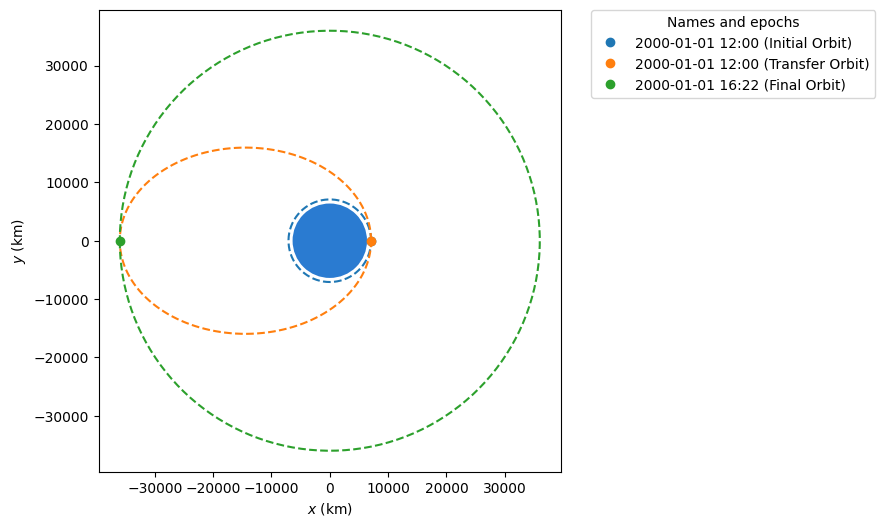

In [40]:
from hapsira.plotting import OrbitPlotter
from hapsira.maneuver import Maneuver
from hapsira.plotting.orbit.backends import Matplotlib2D, Plotly3D

orb_i = Orbit.circular(Earth, 700 << u.km) # create a circular orbit around Earth at 700 km altitude
hoh = Maneuver.hohmann(orb_i, 36000 << u.km) # create a Hohmann maneuver to transfer from the initial orbit to a circular orbit at 1400 km altitude
orbA, orbF = orb_i.apply_maneuver(hoh, intermediate = True) # apply a Hohmann maneuver to the initial orbit and get the resulting orbits

op = OrbitPlotter(backend = Matplotlib2D()) # create an orbital plotter object with matplotlib backend
op.plot(orb_i, label = 'Initial Orbit') # plot the initial orbit
op.plot(orbA, label = 'Transfer Orbit') # plot the transfer orbit
op.plot(orbF, label = 'Final Orbit') # plot the final orbit
op.show() # show the plot

In [ ]:
from astropy.time import Time
from hapsira.ephem import Ephem
from hapsira.twobody.sampling import EpochBounds
from astropy.coordinates import solar_system_ephemeris

solar_system_ephemeris.set("jpl")
# Set dates for launch and arrival of Mars Orbiting Lab
date_launch = Time('2011-11-26 15:02', scale='tdb')
date_arrival = Time('2012-08-06 05:17', scale='tdb')

orb_Launch = Orbit.from_ephem(Sun, Ephem.from_body(Earth, date_launch), date_launch) # create an orbit from the ephemeris of Earth at the launch date
orb_Arrival = Orbit.from_ephem(Sun, Ephem.from_body(Mars, date_arrival), date_arrival) # create an orbit from the ephemeris of Mars at the arrival date

# create a Lambert maneuver to transfer from the launch orbit to the arrival orbit
man_lambert = Maneuver.lambert(orb_Launch, orb_Arrival) 

# Each impulse is (time_offset, delta_v_vector) — unpack both
(t_a, dv_a), (t_b, dv_b) = man_lambert.impulses

# create a transfer orbit from the launch orbit and the delta v required for the Lambert maneuver
orb_transfer = Orbit.from_vectors(Sun, orb_Launch.r, orb_Launch.v + dv_a, epoch = date_launch) 

# get the ephemeris of the transfer orbit
transfer_ephem = orb_transfer.to_ephem(
    strategy = EpochBounds(min_epoch = date_launch, max_epoch = date_arrival)
)

op = OrbitPlotter(backend = Plotly3D()) # create an orbital plotter object with Plotly backend
op.plot_ephem(Ephem.from_body(Earth, date_launch), label = 'Earth at Launch', color = 'blue') # plot the launch orbit
op.plot_ephem(Ephem.from_body(Mars, date_arrival), label = 'Mars at Arrival', color = 'red') # plot the arrival orbit
op.plot_ephem(transfer_ephem, label = 'Transfer Orbit', color = 'green') # plot the transfer orbit
op.show() # show the plot

TypeError: EpochBounds.__init__() got an unexpected keyword argument 'start'